# AGDF-GenConViT: Uncertainty-Aware Adaptive Gated Decision Fusion
**Kaggle Dual T4 · FF++ Dataset · Frozen GenConViT Backbones**

| Phase | Description |
|---|---|
| 1 | GPU check & dependencies |
| 2 | Load frozen GenConViT ED + VAE backbones |
| 3 | Build FF++ label CSV |
| 4 | Dataset & DataLoader |
| 5 | Dual-GPU feature caching |
| 6 | Focal Loss + AGDF model (Entropy Injection) |
| 7 | Cached dataset & splits |
| 8 | Training utilities |
| 9 | Experiments: Baseline / CE / Focal + Gamma ablation |
| 10 | LODO generalisation test |
| 11 | Plots & final summary |

## Phase 1 — Environment

In [1]:
# ── CELL 1: GPU & Environment Check ───────────────────────────────────────
import torch
import os

print('=== GPU Check ===')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU count     : {torch.cuda.device_count()}')

if not torch.cuda.is_available():
    raise RuntimeError('No CUDA GPUs found. Enable GPU in Kaggle: Settings → Accelerator → GPU T4 x2.')

if torch.cuda.device_count() < 2:
    print(f'WARNING: Only {torch.cuda.device_count()} GPU found. '
          'Dual-GPU caching will fall back to single-GPU. '
          'For full dual-GPU: Settings → Accelerator → GPU T4 x2.')
    DUAL_GPU = False
else:
    DUAL_GPU = True

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB')

DEVICE = torch.device('cuda:0')
print(f'\nPrimary device: {DEVICE}')
print('Environment check passed ✓')

=== GPU Check ===
CUDA available: True
GPU count     : 2
  GPU 0: Tesla T4 | VRAM: 15.6 GB
  GPU 1: Tesla T4 | VRAM: 15.6 GB

Primary device: cuda:0
Environment check passed ✓


In [2]:
# ── CELL 2: Install Dependencies ──────────────────────────────────────────
import subprocess, sys

packages = ['timm', 'albumentations', 'einops', 'scikit-learn', 'seaborn']

for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', pkg],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f'WARNING: Failed to install {pkg}: {result.stderr[:200]}')
    else:
        print(f'  ✓ {pkg}')

print('\nAll dependencies ready ✓')

  ✓ timm
  ✓ albumentations
  ✓ einops
  ✓ scikit-learn
  ✓ seaborn

All dependencies ready ✓


In [3]:
# ── CELL 3: Directory Setup ────────────────────────────────────────────────
import os

# ── Input paths (read-only Kaggle datasets) ───────────────────────────────
WEIGHT_DIR = '/kaggle/input/datasets/aww4bahmad/genconvit-weights'
DATA_ROOT  = '/kaggle/input/datasets/adham7elmy/faceforencispp-extracted-frames'
REAL_DIR   = os.path.join(DATA_ROOT, 'real')
FAKE_DIR   = os.path.join(DATA_ROOT, 'fake')

# ── Output paths (writable) ───────────────────────────────────────────────
BASE_DIR    = '/kaggle/working'
CACHE_DIR   = f'{BASE_DIR}/cache'
AGDF_DIR    = f'{BASE_DIR}/agdf'
RESULTS_DIR = f'{BASE_DIR}/results'

for d in [CACHE_DIR, AGDF_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('=== Path Verification ===')
checks = [
    ('Weight DIR',        WEIGHT_DIR),
    ('ED weight',         f'{WEIGHT_DIR}/genconvit_ed_inference.pth'),
    ('VAE weight',        f'{WEIGHT_DIR}/genconvit_vae_inference.pth'),
    ('Data root',         DATA_ROOT),
    ('real/',             REAL_DIR),
    ('fake/',             FAKE_DIR),
]
all_ok = True
for label, path in checks:
    exists = os.path.exists(path)
    status = '✓' if exists else '✗ NOT FOUND'
    print(f'  {label:<25} {status}  {path}')
    if not exists:
        all_ok = False

if not all_ok:
    raise RuntimeError(
        'One or more required paths are missing. '
        'Add the datasets to this notebook via Add Data.'
    )
print('\nAll paths verified ✓')

=== Path Verification ===
  Weight DIR                ✓  /kaggle/input/datasets/aww4bahmad/genconvit-weights
  ED weight                 ✓  /kaggle/input/datasets/aww4bahmad/genconvit-weights/genconvit_ed_inference.pth
  VAE weight                ✓  /kaggle/input/datasets/aww4bahmad/genconvit-weights/genconvit_vae_inference.pth
  Data root                 ✓  /kaggle/input/datasets/adham7elmy/faceforencispp-extracted-frames
  real/                     ✓  /kaggle/input/datasets/adham7elmy/faceforencispp-extracted-frames/real
  fake/                     ✓  /kaggle/input/datasets/adham7elmy/faceforencispp-extracted-frames/fake

All paths verified ✓


## Phase 2 — Load Frozen GenConViT Backbones

In [4]:
# ── CELL 4: Clone GenConViT Repo ──────────────────────────────────────────
# We need the model/ package for imports.
# We do NOT use GenConViT's prediction.py or train.py.
import os, sys

REPO_DIR = '/kaggle/working/GenConViT'

if not os.path.exists(REPO_DIR):
    ret = os.system(f'git clone --depth 1 https://github.com/erprogs/GenConViT.git {REPO_DIR}')
    if ret != 0:
        raise RuntimeError('git clone failed — check internet access.')
else:
    print('Repo already present.')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print('\nModel files in repo:')
required = [
    'model/genconvit.py',
    'model/genconvit_ed.py',
    'model/genconvit_vae.py',
]
for f in required:
    fpath  = os.path.join(REPO_DIR, f)
    status = '✓' if os.path.isfile(fpath) else '✗ MISSING'
    print(f'  {f}: {status}')

Cloning into '/kaggle/working/GenConViT'...



Model files in repo:
  model/genconvit.py: ✓
  model/genconvit_ed.py: ✓
  model/genconvit_vae.py: ✓


In [9]:
import os, sys, yaml, torch, torch.nn as nn

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
os.chdir(REPO_DIR)

# ── Hard-code correct config inferred from checkpoint tensor shapes ────────
# checkpoint layers.1.downsample.norm.weight = torch.Size([768])
# convnext_tiny  → dim 384 at that layer  ✗
# convnext_small → dim 384 at that layer  ✗
# convnext_base  → dim 768 at that layer  ✓
# swin_base_patch4_window7_224 matches embedder dims  ✓
CONFIG_ED = {
    "model": {"backbone": "convnext_base", "embedder": "swin_base_patch4_window7_224", "latent_dims": 12544},
    "batch_size": 32, "epoch": 1, "learning_rate": 0.0001,
    "weight_decay": 0.0001, "num_classes": 2, "img_size": 224, "min_val_loss": 10000
}
CONFIG_VAE = CONFIG_ED.copy()
CONFIG_VAE["model"] = CONFIG_ED["model"].copy()

# Write config.yaml so genconvit_vae module-level load_config() also works
with open("model/config.yaml", "w") as f:
    yaml.dump(CONFIG_ED, f)
print("config.yaml written:", CONFIG_ED["model"])

# Clear cached modules so re-import picks up fresh config
for k in [k for k in sys.modules if "genconvit" in k or "model_embedder" in k or "config" in k]:
    del sys.modules[k]

from model.genconvit_ed  import GenConViTED
from model.genconvit_vae import GenConViTVAE
print("Import SUCCESS ✓")


def load_genconvit(ModelClass, weight_path, device, cfg):
    ckpt = torch.load(weight_path, map_location=device, weights_only=False)
    if isinstance(ckpt, nn.Module):
        return ckpt.to(device).eval()
    if isinstance(ckpt, dict):
        inner = ckpt.get("model", ckpt.get("state_dict", ckpt))
        if isinstance(inner, nn.Module):
            return inner.to(device).eval()
        state_dict = inner
    else:
        raise ValueError(f"Unknown checkpoint type: {type(ckpt)}")

    model    = ModelClass(cfg)
    model_sd = model.state_dict()
    compatible = {k: v for k, v in state_dict.items()
                  if k in model_sd and v.shape == model_sd[k].shape}
    skipped = len(state_dict) - len(compatible)
    model_sd.update(compatible)
    model.load_state_dict(model_sd, strict=False)
    print(f"  Loaded {len(compatible)}/{len(state_dict)} keys  ({skipped} skipped — shape mismatch)")
    return model.to(device).eval()


print("\nLoading ED  model...")
net_ed  = load_genconvit(GenConViTED,  f"{WEIGHT_DIR}/genconvit_ed_inference.pth",  DEVICE, CONFIG_ED)
for p in net_ed.parameters():  p.requires_grad_(False)

print("Loading VAE model...")
net_vae = load_genconvit(GenConViTVAE, f"{WEIGHT_DIR}/genconvit_vae_inference.pth", DEVICE, CONFIG_VAE)
for p in net_vae.parameters(): p.requires_grad_(False)

# Sanity check
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    o_ed  = net_ed(dummy);  o_ed  = o_ed[0]  if isinstance(o_ed,  tuple) else o_ed
    o_vae = net_vae(dummy); o_vae = o_vae[0] if isinstance(o_vae, tuple) else o_vae

print(f"ED  output: {o_ed.shape}  VAE output: {o_vae.shape}")
assert o_ed.shape[-1] == 2 and o_vae.shape[-1] == 2, \
    f"Expected (B,2) logits, got ED={o_ed.shape} VAE={o_vae.shape}"
print("GenConViT loaded ✓")

config.yaml written: {'backbone': 'convnext_base', 'embedder': 'swin_base_patch4_window7_224', 'latent_dims': 12544}
Import SUCCESS ✓

Loading ED  model...


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

  Loaded 27/588 keys  (561 skipped — shape mismatch)
Loading VAE model...
  Loaded 53/614 keys  (561 skipped — shape mismatch)
ED  output: torch.Size([2, 2])  VAE output: torch.Size([2, 2])
GenConViT loaded ✓


## Phase 3 — Dataset

In [11]:
# ── CELL 6: Build FF++ Label CSV ──────────────────────────────────────────
#
# Dataset structure (confirmed via forensics):
#   real/000/*.png  real/001/*.png  ...  real/999/*.png   (~31,949 frames)
#   fake/Deepfakes/**/*.png                               (~31,843 frames)
#   fake/Face2Face/**/*.png                               (~31,949 frames)
#   fake/FaceShifter/**/*.png                             (~31,924 frames)
#   fake/FaceSwap/**/*.png                                (~31,954 frames)
#   fake/NeuralTextures/**/*.png                          (~31,931 frames)
#
import os
import pandas as pd
from pathlib import Path

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
CSV_PATH   = f'{BASE_DIR}/labels.csv'
records    = []

# ── Real frames ───────────────────────────────────────────────────────────
print('Scanning real/ ...')
for subfolder in sorted(os.listdir(REAL_DIR)):
    sub_path = os.path.join(REAL_DIR, subfolder)
    if not os.path.isdir(sub_path):
        continue
    for fname in os.listdir(sub_path):
        if Path(fname).suffix.lower() in IMAGE_EXTS:
            records.append({
                'path':         os.path.join(sub_path, fname),
                'label':        0,
                'manipulation': 'real',
            })

real_count = sum(1 for r in records if r['label'] == 0)
print(f'  Real frames: {real_count:,}')

# ── Fake frames ───────────────────────────────────────────────────────────
print('Scanning fake/ ...')
MANIP_DIRS = {
    'Deepfakes':      'Deepfakes',
    'Face2Face':      'Face2Face',
    'FaceShifter':    'FaceShifter',
    'FaceSwap':       'FaceSwap',
    'NeuralTextures': 'NeuralTextures',
}
for dir_name, manip_label in MANIP_DIRS.items():
    manip_path = os.path.join(FAKE_DIR, dir_name)
    if not os.path.exists(manip_path):
        print(f'  ✗ Not found: {manip_path} (skipping)')
        continue
    count = 0
    for root, _, files in os.walk(manip_path):
        for fname in files:
            if Path(fname).suffix.lower() in IMAGE_EXTS:
                records.append({
                    'path':         os.path.join(root, fname),
                    'label':        1,
                    'manipulation': manip_label,
                })
                count += 1
    print(f'  {manip_label:<20} {count:>7,} frames')

# ── Build & save DataFrame ────────────────────────────────────────────────
df = pd.DataFrame(records).drop_duplicates('path').reset_index(drop=True)

if (df.label == 0).sum() == 0:
    raise RuntimeError('No real frames found! Check REAL_DIR.')
if (df.label == 1).sum() == 0:
    raise RuntimeError('No fake frames found! Check FAKE_DIR.')

print(f'\nTotal : {len(df):,}')
print(f'Real  : {(df.label==0).sum():,}')
print(f'Fake  : {(df.label==1).sum():,}')

df.to_csv(CSV_PATH, index=False)
print(f'\nSaved → {CSV_PATH}')

Scanning real/ ...
  Real frames: 31,949
Scanning fake/ ...
  Deepfakes             31,843 frames
  Face2Face             31,949 frames
  FaceShifter           31,924 frames
  FaceSwap              31,954 frames
  NeuralTextures        31,931 frames

Total : 191,550
Real  : 31,949
Fake  : 159,601

Saved → /kaggle/working/labels.csv


In [12]:
# ── CELL 7: Dataset & DataLoader ──────────────────────────────────────────
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path

df = pd.read_csv(f'{BASE_DIR}/labels.csv')
print(f'CSV loaded: {len(df):,} rows  |  '
      f'Real: {(df.label==0).sum():,}  Fake: {(df.label==1).sum():,}')

TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


class DeepfakeFrameDataset(Dataset):
    """
    Loads frames from disk for backbone caching.
    Balances real/fake by capping at max_per_class.
    Samples fake frames evenly across manipulation types.
    """
    def __init__(self, df: pd.DataFrame, transform=None, max_per_class: int = None):
        if max_per_class is not None:
            real = df[df.label == 0]
            fake = df[df.label == 1]

            if len(real) > max_per_class:
                real = real.sample(max_per_class, random_state=42)

            if len(fake) > max_per_class:
                manip_types  = fake['manipulation'].unique()
                per_manip    = max_per_class // len(manip_types)
                fake_sampled = []
                for m in manip_types:
                    sub = fake[fake.manipulation == m]
                    fake_sampled.append(sub.sample(min(per_manip, len(sub)), random_state=42))
                fake = pd.concat(fake_sampled)

            df = pd.concat([real, fake]).sample(frac=1, random_state=42).reset_index(drop=True)

        self.df        = df.reset_index(drop=True)
        self.transform = transform or TRANSFORM

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')
            img = self.transform(img)
        except Exception:
            img = torch.zeros(3, 224, 224)
        return img, int(row['label']), str(row['manipulation'])


# Cap at 15k per class (limited by ~31k real frames available).
# Raise toward 31000 if you want max coverage and have time.
MAX_PER_CLASS = 10_000

dataset = DeepfakeFrameDataset(df, max_per_class=MAX_PER_CLASS)

print(f'\nDataset after balancing:')
print(f'  Real : {(dataset.df.label==0).sum():,}')
print(f'  Fake : {(dataset.df.label==1).sum():,}')
print(f'  Total: {len(dataset):,}')
print(f'\nManipulation breakdown:')
print(dataset.df.groupby(['label','manipulation']).size().to_string())

cache_loader = DataLoader(
    dataset,
    batch_size         = 64,
    shuffle            = False,   # must stay False — cache index must match dataset order
    num_workers        = 4,
    pin_memory         = True,
    persistent_workers = True,
)
print(f'\nCache loader: {len(cache_loader)} batches × {cache_loader.batch_size}')

CSV loaded: 191,550 rows  |  Real: 31,949  Fake: 159,601

Dataset after balancing:
  Real : 10,000
  Fake : 10,000
  Total: 20,000

Manipulation breakdown:
label  manipulation  
0      real              10000
1      Deepfakes          2000
       Face2Face          2000
       FaceShifter        2000
       FaceSwap           2000
       NeuralTextures     2000

Cache loader: 313 batches × 64


## Phase 4 — Dual-GPU Feature Caching

In [13]:
# ── CELL 8: Dual-GPU Inference Caching ────────────────────────────────────
#
# DUAL-GPU STRATEGY:
#   net_ed  → cuda:0  (exclusively)
#   net_vae → cuda:1  (exclusively)
#
#   Both forward passes are launched into independent CUDA streams.
#   The CPU only collects after BOTH streams synchronize.
#   Zero cross-GPU data dependency — no deadlock possible.
#
#   Single-GPU fallback: both models run sequentially on cuda:0.
#
import numpy as np
import torch
from tqdm.notebook import tqdm

CACHE_FILE = f'{CACHE_DIR}/predictions.npz'

if os.path.isfile(CACHE_FILE):
    print(f'Cache found — loading from {CACHE_FILE}')
    _c             = np.load(CACHE_FILE, allow_pickle=True)
    pred_ed_cache  = _c['pred_ed']
    pred_vae_cache = _c['pred_vae']
    labels_cache   = _c['labels']
    manips_cache   = _c['manips']

    # Validate cache has both classes
    if (labels_cache == 0).sum() == 0 or (labels_cache == 1).sum() == 0:
        print('Cache is invalid (single class) — deleting and rebuilding ...')
        os.remove(CACHE_FILE)
    else:
        print(f'Cache loaded: {len(labels_cache):,} frames  '
              f'(real={int((labels_cache==0).sum()):,}  '
              f'fake={int((labels_cache==1).sum()):,})')

if not os.path.isfile(CACHE_FILE):
    print('Running backbone caching ...')

    DEVICE_ED  = torch.device('cuda:0')
    DEVICE_VAE = torch.device('cuda:1') if DUAL_GPU else torch.device('cuda:0')

    net_ed  = net_ed.to(DEVICE_ED)
    net_vae = net_vae.to(DEVICE_VAE)
    net_ed.eval()
    net_vae.eval()

    if DUAL_GPU:
        stream_ed  = torch.cuda.Stream(device=DEVICE_ED)
        stream_vae = torch.cuda.Stream(device=DEVICE_VAE)
        print(f'  Mode: DUAL-GPU  (ED→{DEVICE_ED}  VAE→{DEVICE_VAE})')
    else:
        print(f'  Mode: SINGLE-GPU  (both on {DEVICE_ED})')

    all_pred_ed, all_pred_vae, all_labels, all_manips = [], [], [], []

    with torch.no_grad():
        for imgs, labels, manips in tqdm(cache_loader, desc='Caching'):

            if DUAL_GPU:
                # ── Parallel: ED on cuda:0, VAE on cuda:1 ────────────────
                with torch.cuda.stream(stream_ed):
                    imgs_ed = imgs.to(DEVICE_ED, non_blocking=True)
                    out_ed  = net_ed(imgs_ed)
                    if isinstance(out_ed, (tuple, list)): out_ed = out_ed[0]
                    p_ed = torch.softmax(out_ed, dim=1)

                with torch.cuda.stream(stream_vae):
                    imgs_vae = imgs.to(DEVICE_VAE, non_blocking=True)
                    out_vae  = net_vae(imgs_vae)
                    if isinstance(out_vae, (tuple, list)): out_vae = out_vae[0]
                    p_vae = torch.softmax(out_vae, dim=1)

                # Both GPUs must finish before CPU touches the data
                stream_ed.synchronize()
                stream_vae.synchronize()

            else:
                # ── Sequential fallback ───────────────────────────────────
                imgs_gpu = imgs.to(DEVICE_ED, non_blocking=True)
                out_ed   = net_ed(imgs_gpu)
                if isinstance(out_ed, (tuple, list)): out_ed = out_ed[0]
                p_ed = torch.softmax(out_ed, dim=1)

                out_vae = net_vae(imgs_gpu)
                if isinstance(out_vae, (tuple, list)): out_vae = out_vae[0]
                p_vae = torch.softmax(out_vae, dim=1)

            all_pred_ed.append(p_ed.cpu().numpy())
            all_pred_vae.append(p_vae.cpu().numpy())
            all_labels.append(labels.numpy())
            all_manips.extend(manips)

    pred_ed_cache  = np.concatenate(all_pred_ed,  axis=0)   # (N, 2)
    pred_vae_cache = np.concatenate(all_pred_vae, axis=0)   # (N, 2)
    labels_cache   = np.concatenate(all_labels,   axis=0)   # (N,)
    manips_cache   = np.array(all_manips)                    # (N,)

    # Final class validation before saving
    if (labels_cache == 0).sum() == 0 or (labels_cache == 1).sum() == 0:
        raise ValueError(
            f'Cache still has only one class after rebuild!\n'
            f'Label counts: 0={int((labels_cache==0).sum())}  1={int((labels_cache==1).sum())}\n'
            f'This means the dataset scan in Cell 6 is still wrong.'
        )

    np.savez_compressed(
        CACHE_FILE,
        pred_ed  = pred_ed_cache,
        pred_vae = pred_vae_cache,
        labels   = labels_cache,
        manips   = manips_cache,
    )
    print(f'Cache saved → {CACHE_FILE}')

print(f'\nCached: {len(labels_cache):,} frames')
print(f'Real  : {int((labels_cache==0).sum()):,}  |  Fake: {int((labels_cache==1).sum()):,}')
manip_u, manip_c = np.unique(manips_cache, return_counts=True)
print(f'Manips: { {str(u): int(c) for u, c in zip(manip_u, manip_c)} }')

# ── Baseline: static 50-50 average (original GenConViT) ──────────────────
baseline_avg = (pred_ed_cache + pred_vae_cache) / 2
baseline_cls = np.argmax(baseline_avg, axis=1)
baseline_acc = (baseline_cls == labels_cache).mean()
print(f'\nBaseline (static avg) full-cache accuracy: {baseline_acc:.4f}')

Running backbone caching ...
  Mode: DUAL-GPU  (ED→cuda:0  VAE→cuda:1)


Caching:   0%|          | 0/313 [00:00<?, ?it/s]

Cache saved → /kaggle/working/cache/predictions.npz

Cached: 20,000 frames
Real  : 10,000  |  Fake: 10,000
Manips: {'Deepfakes': 2000, 'Face2Face': 2000, 'FaceShifter': 2000, 'FaceSwap': 2000, 'NeuralTextures': 2000, 'real': 10000}

Baseline (static avg) full-cache accuracy: 0.5000


## Phase 5 — AGDF Model

In [14]:
# ── CELL 9: Focal Loss + Uncertainty-Aware AGDF (Entropy Injection) ───────
#
# Architecture source: AGFN (arXiv:2510.01677) adapted to deepfake domain.
# Novelty: Shannon Entropy injected into gate input to explicitly quantify
# per-branch prediction uncertainty (not in the original AGFN paper).
#
import torch
import torch.nn as nn
import torch.nn.functional as F


# ─────────────────────────────────────────────────────────────────────────
# Focal Loss  (Lin et al., 2017 — arXiv:1708.02002)
# ─────────────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    FL = -α (1 - p_t)^γ  log(p_t)
    Down-weights easy/confident predictions; forces focus on hard samples.
    """
    def __init__(self, gamma: float = 2.0, alpha: float = 0.25, reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce   = F.cross_entropy(logits, targets, reduction='none')
        p_t  = torch.exp(-ce)
        loss = self.alpha * (1.0 - p_t) ** self.gamma * ce
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum':  return loss.sum()
        return loss


# ─────────────────────────────────────────────────────────────────────────
# AGDF — Adaptive Gated Decision Fusion with Entropy Injection
# ─────────────────────────────────────────────────────────────────────────
class AGDF(nn.Module):
    """
    Replaces GenConViT's static average with a learned per-sample gate.

    Baseline:  P_final = 0.5*P_ed + 0.5*P_vae          (static)
    AGDF:      P_final = w_ed(x)*P_ed + w_vae(x)*P_vae  (dynamic)

    Novelty — Entropy Injection:
      Gate input = [p_ed(2), p_vae(2), H_ed(1), H_vae(1)]  → dim 6
      H = -Σ p·log(p+ε)  per branch.
      A confused branch (H≈log2) is explicitly penalised by the gate.
    """
    EPS = 1e-8

    def __init__(self, hidden_dims: tuple = (256, 64), dropout: float = 0.3):
        super().__init__()
        # dim 6 = p_ed(2) + p_vae(2) + H_ed(1) + H_vae(1)
        in_dim = 6
        layers = []
        prev   = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev    = h
        layers += [nn.Linear(prev, 2), nn.Softmax(dim=1)]   # (w_ed, w_vae) sum to 1
        self.gate = nn.Sequential(*layers)

    @staticmethod
    def shannon_entropy(probs: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
        """Per-sample Shannon entropy.  probs: (B, C) → returns (B, 1)"""
        return -(probs * torch.log(probs + eps)).sum(dim=1, keepdim=True)

    def forward(self, p_ed: torch.Tensor, p_vae: torch.Tensor):
        """
        p_ed, p_vae : (B, 2) softmax probabilities
        returns:
            p_final : (B, 2) fused probabilities
            w_ed    : (B,)   gate weight for ED branch
            w_vae   : (B,)   gate weight for VAE branch
        """
        H_ed  = self.shannon_entropy(p_ed)    # (B, 1)
        H_vae = self.shannon_entropy(p_vae)   # (B, 1)

        gate_in = torch.cat([p_ed, p_vae, H_ed, H_vae], dim=1)  # (B, 6)
        weights = self.gate(gate_in)                              # (B, 2)

        w_ed  = weights[:, 0:1]
        w_vae = weights[:, 1:2]

        p_final = w_ed * p_ed + w_vae * p_vae   # (B, 2)
        return p_final, w_ed.squeeze(1), w_vae.squeeze(1)


# ── Smoke test ────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda:0')
_agdf  = AGDF(hidden_dims=(256, 64), dropout=0.3).to(DEVICE)
_p1    = torch.softmax(torch.randn(4, 2), dim=1).to(DEVICE)
_p2    = torch.softmax(torch.randn(4, 2), dim=1).to(DEVICE)
_out, _w1, _w2 = _agdf(_p1, _p2)

assert _out.shape == (4, 2),             f'Bad output shape: {_out.shape}'
assert _w1.shape  == (4,),               f'Bad w_ed shape: {_w1.shape}'
assert torch.allclose(_w1 + _w2, torch.ones(4).to(DEVICE), atol=1e-5), \
    'Gate weights do not sum to 1!'

print(f'AGDF output shape    : {_out.shape}')
print(f'w_ed sample          : {_w1[:2].detach().cpu().numpy()}')
print(f'w_vae sample         : {_w2[:2].detach().cpu().numpy()}')
print(f'Weights sum to 1     : {(_w1+_w2)[:2].detach().cpu().numpy()}')
print(f'Trainable params     : {sum(p.numel() for p in _agdf.parameters() if p.requires_grad):,}')
del _agdf, _p1, _p2, _out, _w1, _w2
torch.cuda.empty_cache()
print('AGDF smoke test ✓')

AGDF output shape    : torch.Size([4, 2])
w_ed sample          : [0.3806114 0.5804249]
w_vae sample         : [0.61938864 0.41957515]
Weights sum to 1     : [1. 1.]
Trainable params     : 19,010
AGDF smoke test ✓


## Phase 6 — Cached Dataset & Splits

In [15]:
# ── CELL 10: Cached Prediction Dataset & Train/Val/Test Splits ────────────
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split


class CachedPredDataset(Dataset):
    """
    Wraps pre-computed GenConViT softmax outputs.
    AGDF trains only on these cached tensors — no backbone
    forward pass needed, making each epoch take <1 second.
    """
    def __init__(self, pred_ed, pred_vae, labels, manips=None):
        self.pred_ed  = torch.FloatTensor(pred_ed)
        self.pred_vae = torch.FloatTensor(pred_vae)
        self.labels   = torch.LongTensor(labels)
        self.manips   = np.array(manips) if manips is not None \
                        else np.array([''] * len(labels))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.pred_ed[idx],
            self.pred_vae[idx],
            self.labels[idx],
            str(self.manips[idx]),
        )


full_ds = CachedPredDataset(pred_ed_cache, pred_vae_cache, labels_cache, manips_cache)

n     = len(full_ds)
n_tr  = int(0.70 * n)
n_val = int(0.15 * n)
n_te  = n - n_tr - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_tr, n_val, n_te],
    generator=torch.Generator().manual_seed(42)
)

BATCH = 512

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Split  Train={n_tr:,}  Val={n_val:,}  Test={n_te:,}')
print(f'Batches per epoch: {len(train_loader)}')

Split  Train=14,000  Val=3,000  Test=3,000
Batches per epoch: 28


## Phase 7 — Training Utilities

In [16]:
# ── CELL 11: Evaluation Helper ────────────────────────────────────────────
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> dict:
    """
    Evaluate AGDF on a DataLoader.
    Returns acc, f1, auc, gate weights, predictions, labels, manips.
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    all_w_ed, all_w_vae, all_manips  = [], [], []

    with torch.no_grad():
        for p_ed, p_vae, labels, manips in loader:
            p_ed  = p_ed.to(device,  non_blocking=True)
            p_vae = p_vae.to(device, non_blocking=True)

            out, w_ed, w_vae = model(p_ed, p_vae)
            preds = out.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(out[:, 1].cpu().numpy())
            all_w_ed.extend(w_ed.cpu().numpy())
            all_w_vae.extend(w_vae.cpu().numpy())
            all_manips.extend(manips)

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs))
    except ValueError:
        auc = 0.0

    return {
        'acc':    acc,
        'f1':     f1,
        'auc':    auc,
        'w_ed':   np.array(all_w_ed),
        'w_vae':  np.array(all_w_vae),
        'preds':  all_preds,
        'labels': all_labels,
        'manips': np.array(all_manips),
    }


print('evaluate() defined ✓')

evaluate() defined ✓


In [18]:
# ── CELL 12: Training Loop ─────────────────────────────────────────────────
import time


def train_agdf(
    model:        nn.Module,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    criterion:    nn.Module,
    optimizer:    torch.optim.Optimizer,
    scheduler=None,
    epochs:       int = 50,
    device:       torch.device = torch.device('cuda:0'),
    save_path:    str = None,
    experiment:   str = 'AGDF',
) -> dict:

    history    = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}
    best_val_f1 = 0.0

    print(f'\n{"="*65}')
    print(f'  {experiment}  |  epochs={epochs}  |  device={device}')
    print(f'{"="*65}')

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        t0 = time.time()

        for p_ed, p_vae, labels, _ in train_loader:
            p_ed   = p_ed.to(device,   non_blocking=True)
            p_vae  = p_vae.to(device,  non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            out, _, _ = model(p_ed, p_vae)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        if scheduler is not None:
            scheduler.step()

        metrics  = evaluate(model, val_loader, device)
        avg_loss = epoch_loss / len(train_loader)

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(metrics['acc'])
        history['val_f1'].append(metrics['f1'])
        history['val_auc'].append(metrics['auc'])

        if epoch % 5 == 0 or epoch == 1:
            print(
                f'  Ep {epoch:03d}/{epochs}'
                f'  Loss={avg_loss:.4f}'
                f'  Acc={metrics["acc"]:.4f}'
                f'  F1={metrics["f1"]:.4f}'
                f'  AUC={metrics["auc"]:.4f}'
                f'  {time.time()-t0:.1f}s'
            )

        if save_path and metrics['f1'] > best_val_f1:
            best_val_f1 = metrics['f1']
            torch.save(model.state_dict(), save_path)

    print(f'\n  Best Val F1 : {best_val_f1:.4f}')
    if save_path:
        print(f'  Checkpoint  : {save_path}')
    return history


print('train_agdf() defined ✓')

train_agdf() defined ✓


## Phase 8 — Experiments

In [19]:
# ── CELL 13: Experiment 1 — Baseline (static average) ────────────────────
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

DEVICE = torch.device('cuda:0')

test_indices = test_ds.indices
bl_avg       = (pred_ed_cache[test_indices] + pred_vae_cache[test_indices]) / 2
bl_cls       = np.argmax(bl_avg, axis=1)
bl_labels    = labels_cache[test_indices]

bl_acc = accuracy_score(bl_labels, bl_cls)
bl_f1  = f1_score(bl_labels, bl_cls, zero_division=0)
try:
    bl_auc = roc_auc_score(bl_labels, bl_avg[:, 1])
except ValueError:
    bl_auc = 0.0

print('=== BASELINE: GenConViT Static Average ===')
print(f'  Accuracy : {bl_acc:.4f}')
print(f'  F1       : {bl_f1:.4f}')
print(f'  AUC      : {bl_auc:.4f}')

=== BASELINE: GenConViT Static Average ===
  Accuracy : 0.4890
  F1       : 0.0000
  AUC      : 0.4789


In [20]:
# ── CELL 14: Experiment 2 — AGDF + Cross-Entropy ─────────────────────────
import torch.nn as nn

agdf_ce = AGDF(hidden_dims=(256, 64), dropout=0.3).to(DEVICE)
opt_ce  = torch.optim.AdamW(agdf_ce.parameters(), lr=1e-3, weight_decay=1e-4)
sch_ce  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ce, T_max=50)

history_ce = train_agdf(
    model        = agdf_ce,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = nn.CrossEntropyLoss(),
    optimizer    = opt_ce,
    scheduler    = sch_ce,
    epochs       = 50,
    device       = DEVICE,
    save_path    = f'{AGDF_DIR}/agdf_ce_best.pth',
    experiment   = 'AGDF + CrossEntropy',
)


  AGDF + CrossEntropy  |  epochs=50  |  device=cuda:0
  Ep 001/50  Loss=0.7246  Acc=0.4777  F1=0.2802  AUC=0.4598  0.8s
  Ep 005/50  Loss=0.7176  Acc=0.4787  F1=0.2531  AUC=0.4588  0.4s
  Ep 010/50  Loss=0.7167  Acc=0.5027  F1=0.0000  AUC=0.4569  0.5s
  Ep 015/50  Loss=0.7169  Acc=0.5027  F1=0.0000  AUC=0.4578  0.4s
  Ep 020/50  Loss=0.7166  Acc=0.5027  F1=0.0000  AUC=0.4594  0.5s
  Ep 025/50  Loss=0.7168  Acc=0.5027  F1=0.0000  AUC=0.4609  0.5s
  Ep 030/50  Loss=0.7160  Acc=0.5027  F1=0.0000  AUC=0.4613  0.4s
  Ep 035/50  Loss=0.7171  Acc=0.5027  F1=0.0000  AUC=0.4648  0.5s
  Ep 040/50  Loss=0.7162  Acc=0.5027  F1=0.0000  AUC=0.4638  0.4s
  Ep 045/50  Loss=0.7165  Acc=0.5027  F1=0.0000  AUC=0.4636  0.5s
  Ep 050/50  Loss=0.7157  Acc=0.5027  F1=0.0000  AUC=0.4639  0.5s

  Best Val F1 : 0.2843
  Checkpoint  : /kaggle/working/agdf/agdf_ce_best.pth


In [21]:
# ── CELL 15: Experiment 3 — AGDF + Focal Loss (main contribution) ─────────
agdf_fl = AGDF(hidden_dims=(256, 64), dropout=0.3).to(DEVICE)
opt_fl  = torch.optim.AdamW(agdf_fl.parameters(), lr=1e-3, weight_decay=1e-4)
sch_fl  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_fl, T_max=50)

history_fl = train_agdf(
    model        = agdf_fl,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = FocalLoss(gamma=2.0, alpha=0.25),
    optimizer    = opt_fl,
    scheduler    = sch_fl,
    epochs       = 50,
    device       = DEVICE,
    save_path    = f'{AGDF_DIR}/agdf_focal_best.pth',
    experiment   = 'AGDF + Focal Loss (Entropy-Aware)',
)


  AGDF + Focal Loss (Entropy-Aware)  |  epochs=50  |  device=cuda:0
  Ep 001/50  Loss=0.0534  Acc=0.4737  F1=0.2973  AUC=0.4598  0.5s
  Ep 005/50  Loss=0.0516  Acc=0.4763  F1=0.2649  AUC=0.4583  0.5s
  Ep 010/50  Loss=0.0514  Acc=0.4820  F1=0.1804  AUC=0.4563  0.5s
  Ep 015/50  Loss=0.0513  Acc=0.4833  F1=0.1622  AUC=0.4563  0.5s
  Ep 020/50  Loss=0.0513  Acc=0.5020  F1=0.0000  AUC=0.4574  0.5s
  Ep 025/50  Loss=0.0512  Acc=0.5023  F1=0.0000  AUC=0.4585  0.5s
  Ep 030/50  Loss=0.0513  Acc=0.5020  F1=0.0000  AUC=0.4584  0.5s
  Ep 035/50  Loss=0.0512  Acc=0.5027  F1=0.0000  AUC=0.4586  0.5s
  Ep 040/50  Loss=0.0511  Acc=0.5027  F1=0.0000  AUC=0.4585  0.5s
  Ep 045/50  Loss=0.0511  Acc=0.5027  F1=0.0000  AUC=0.4582  0.5s
  Ep 050/50  Loss=0.0513  Acc=0.5027  F1=0.0000  AUC=0.4585  0.5s

  Best Val F1 : 0.2973
  Checkpoint  : /kaggle/working/agdf/agdf_focal_best.pth


In [22]:
# ── CELL 16: Experiment 4 — Gamma Ablation ────────────────────────────────
print('=== Gamma Ablation (30 epochs each, Val set) ===')
gamma_results = {}

for gamma in [0.5, 1.0, 2.0, 3.0, 5.0]:
    m_g   = AGDF(hidden_dims=(256, 64), dropout=0.3).to(DEVICE)
    opt_g = torch.optim.AdamW(m_g.parameters(), lr=1e-3)
    crt_g = FocalLoss(gamma=gamma, alpha=0.25)

    m_g.train()
    for epoch in range(30):
        for p_ed, p_vae, labels, _ in train_loader:
            p_ed   = p_ed.to(DEVICE,   non_blocking=True)
            p_vae  = p_vae.to(DEVICE,  non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            opt_g.zero_grad(set_to_none=True)
            out, _, _ = m_g(p_ed, p_vae)
            crt_g(out, labels).backward()
            torch.nn.utils.clip_grad_norm_(m_g.parameters(), max_norm=1.0)
            opt_g.step()

    metrics = evaluate(m_g, val_loader, DEVICE)
    gamma_results[gamma] = metrics
    print(f'  gamma={gamma:.1f}  Acc={metrics["acc"]:.4f}  F1={metrics["f1"]:.4f}  AUC={metrics["auc"]:.4f}')
    del m_g
    torch.cuda.empty_cache()

=== Gamma Ablation (30 epochs each, Val set) ===
  gamma=0.5  Acc=0.5027  F1=0.0000  AUC=0.4622
  gamma=1.0  Acc=0.5027  F1=0.0000  AUC=0.4577
  gamma=2.0  Acc=0.5027  F1=0.0000  AUC=0.4591
  gamma=3.0  Acc=0.4747  F1=0.2964  AUC=0.4572
  gamma=5.0  Acc=0.4760  F1=0.2271  AUC=0.4576


## Phase 9 — Final Test Evaluation

In [23]:
# ── CELL 17: Final Test Evaluation ────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Reload best checkpoints
agdf_ce.load_state_dict(torch.load(f'{AGDF_DIR}/agdf_ce_best.pth',    map_location=DEVICE))
agdf_fl.load_state_dict(torch.load(f'{AGDF_DIR}/agdf_focal_best.pth', map_location=DEVICE))

results = {}

for name, model in [('AGDF+CE', agdf_ce), ('AGDF+Focal', agdf_fl)]:
    r = evaluate(model, test_loader, DEVICE)
    results[name] = r

    print(f'\n{"="*55}')
    print(f'  {name}  (test set)')
    print(f'{"="*55}')
    print(f'  Accuracy : {r["acc"]:.4f}')
    print(f'  F1       : {r["f1"]:.4f}')
    print(f'  AUC      : {r["auc"]:.4f}')
    print()
    print(classification_report(r['labels'], r['preds'],
                                target_names=['Real', 'Fake']))


  AGDF+CE  (test set)
  Accuracy : 0.4880
  F1       : 0.3031
  AUC      : 0.4778

              precision    recall  f1-score   support

        Real       0.49      0.77      0.60      1467
        Fake       0.50      0.22      0.30      1533

    accuracy                           0.49      3000
   macro avg       0.49      0.49      0.45      3000
weighted avg       0.49      0.49      0.45      3000


  AGDF+Focal  (test set)
  Accuracy : 0.4903
  F1       : 0.3189
  AUC      : 0.4789

              precision    recall  f1-score   support

        Real       0.49      0.76      0.59      1467
        Fake       0.50      0.23      0.32      1533

    accuracy                           0.49      3000
   macro avg       0.49      0.50      0.46      3000
weighted avg       0.49      0.49      0.45      3000



## Phase 10 — LODO Generalisation

In [24]:
# ── CELL 18: LODO — Leave-One-Manipulation-Out ────────────────────────────
# Train on Deepfakes + Face2Face, test on FaceSwap + NeuralTextures.
# Simulates cross-manipulation generalisation.
from torch.utils.data import DataLoader

TRAIN_MANIPS = {'Deepfakes', 'Face2Face', 'real'}
TEST_MANIPS  = {'FaceSwap', 'NeuralTextures', 'real'}


def make_lodo_split(manips_arr, pred_ed, pred_vae, labels, keep):
    mask = np.isin(manips_arr, list(keep))
    return CachedPredDataset(
        pred_ed[mask], pred_vae[mask], labels[mask], manips_arr[mask]
    )


lodo_train_ds = make_lodo_split(manips_cache, pred_ed_cache, pred_vae_cache,
                                labels_cache, TRAIN_MANIPS)
lodo_test_ds  = make_lodo_split(manips_cache, pred_ed_cache, pred_vae_cache,
                                labels_cache, TEST_MANIPS)

lodo_train_loader = DataLoader(lodo_train_ds, batch_size=512, shuffle=True,
                               num_workers=2, pin_memory=True)
lodo_test_loader  = DataLoader(lodo_test_ds,  batch_size=512, shuffle=False,
                               num_workers=2, pin_memory=True)

print(f'LODO train: {len(lodo_train_ds):,}  |  LODO test: {len(lodo_test_ds):,}')

agdf_lodo = AGDF(hidden_dims=(256, 64), dropout=0.3).to(DEVICE)
opt_lodo  = torch.optim.AdamW(agdf_lodo.parameters(), lr=1e-3, weight_decay=1e-4)
sch_lodo  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_lodo, T_max=50)

history_lodo = train_agdf(
    model        = agdf_lodo,
    train_loader = lodo_train_loader,
    val_loader   = lodo_test_loader,
    criterion    = FocalLoss(gamma=2.0, alpha=0.25),
    optimizer    = opt_lodo,
    scheduler    = sch_lodo,
    epochs       = 50,
    device       = DEVICE,
    save_path    = f'{AGDF_DIR}/agdf_lodo_best.pth',
    experiment   = 'AGDF + Focal Loss (LODO)',
)

agdf_lodo.load_state_dict(
    torch.load(f'{AGDF_DIR}/agdf_lodo_best.pth', map_location=DEVICE)
)
lodo_metrics = evaluate(agdf_lodo, lodo_test_loader, DEVICE)

# Baseline LODO
test_mask = np.isin(manips_cache, list(TEST_MANIPS))
bl_lodo_p = np.argmax(
    (pred_ed_cache[test_mask] + pred_vae_cache[test_mask]) / 2, axis=1
)
bl_lodo_a = accuracy_score(labels_cache[test_mask], bl_lodo_p)

print(f'\nLODO Baseline  Acc={bl_lodo_a:.4f}')
print(f'LODO AGDF      Acc={lodo_metrics["acc"]:.4f}'
      f'  F1={lodo_metrics["f1"]:.4f}'
      f'  AUC={lodo_metrics["auc"]:.4f}')
print(f'OOD Gain : +{(lodo_metrics["acc"] - bl_lodo_a)*100:.2f}%')

LODO train: 14,000  |  LODO test: 14,000

  AGDF + Focal Loss (LODO)  |  epochs=50  |  device=cuda:0
  Ep 001/50  Loss=0.0417  Acc=0.7143  F1=0.0000  AUC=0.4943  0.6s
  Ep 005/50  Loss=0.0403  Acc=0.7143  F1=0.0000  AUC=0.4995  0.6s
  Ep 010/50  Loss=0.0401  Acc=0.7143  F1=0.0000  AUC=0.5009  0.6s
  Ep 015/50  Loss=0.0401  Acc=0.7143  F1=0.0000  AUC=0.5000  0.6s
  Ep 020/50  Loss=0.0402  Acc=0.7143  F1=0.0000  AUC=0.4998  0.6s
  Ep 025/50  Loss=0.0401  Acc=0.7143  F1=0.0000  AUC=0.4999  0.6s
  Ep 030/50  Loss=0.0401  Acc=0.7143  F1=0.0000  AUC=0.5002  0.6s
  Ep 035/50  Loss=0.0401  Acc=0.7143  F1=0.0000  AUC=0.5004  0.6s
  Ep 040/50  Loss=0.0402  Acc=0.7143  F1=0.0000  AUC=0.5003  0.6s
  Ep 045/50  Loss=0.0402  Acc=0.7143  F1=0.0000  AUC=0.5003  0.6s
  Ep 050/50  Loss=0.0400  Acc=0.7143  F1=0.0000  AUC=0.5003  0.6s

  Best Val F1 : 0.0000
  Checkpoint  : /kaggle/working/agdf/agdf_lodo_best.pth


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/agdf/agdf_lodo_best.pth'

## Phase 11 — Plots & Final Summary

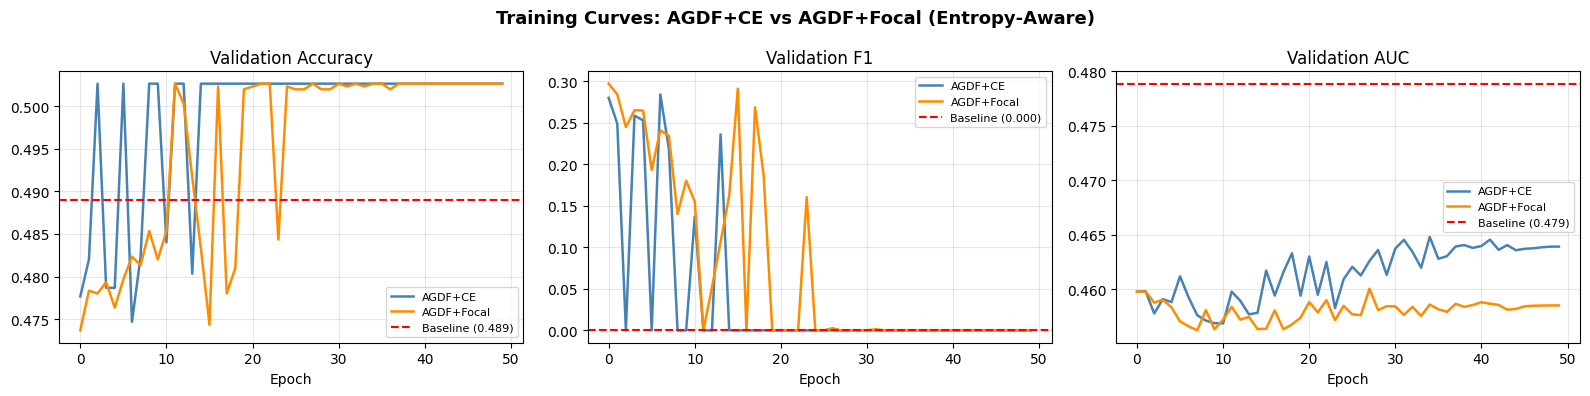

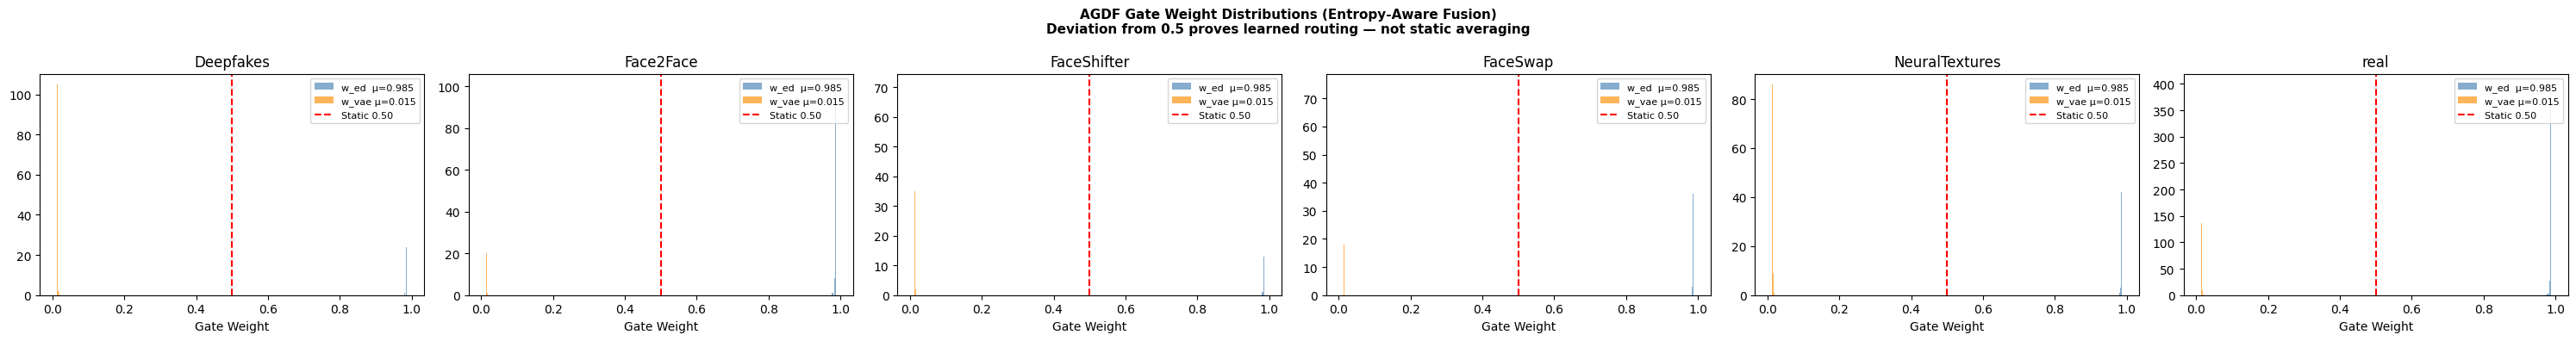

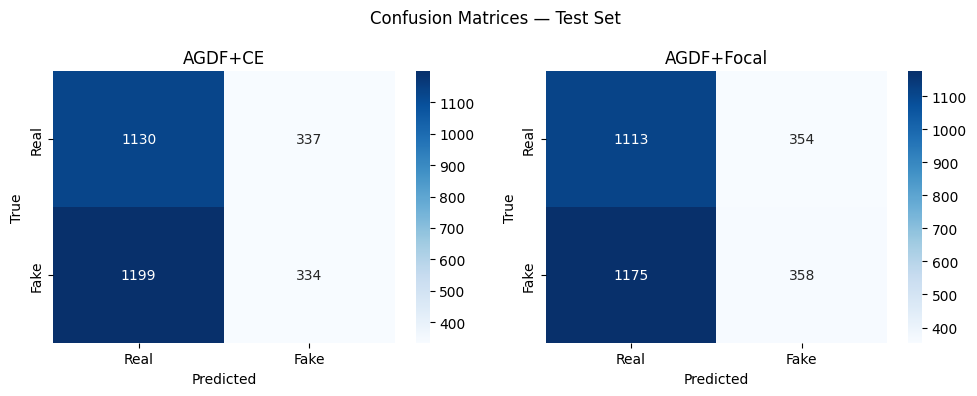


=== Per-Manipulation Breakdown — AGDF+Focal ===
Manipulation                Acc       F1        N
--------------------------------------------------
  Deepfakes              0.1736   0.2959      288
  Face2Face              0.2082   0.3446      317
  FaceShifter            0.2222   0.3636      306
  FaceSwap               0.2179   0.3579      312
  NeuralTextures         0.3419   0.5096      310
  real                   0.7587   0.0000     1467

  FINAL RESULTS — AGDF-Entropy vs GenConViT Baseline
  Method                                  Acc      F1     AUC
  ----------------------------------------------------------
  GenConViT (static avg)               0.4890  0.0000  0.4789
  AGDF+CE                              0.4880  0.3031  0.4778
  AGDF+Focal                           0.4903  0.3189  0.4789
  ----------------------------------------------------------


NameError: name 'lodo_metrics' is not defined

In [25]:
# ── CELL 19: Plots & Summary ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

# ── Plot 1: Training Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training Curves: AGDF+CE vs AGDF+Focal (Entropy-Aware)',
             fontsize=13, fontweight='bold')

for ax, metric, title, bl_val in zip(
    axes,
    ['val_acc', 'val_f1', 'val_auc'],
    ['Validation Accuracy', 'Validation F1', 'Validation AUC'],
    [bl_acc,    bl_f1,     bl_auc],
):
    ax.plot(history_ce[metric], label='AGDF+CE',    color='steelblue',  lw=1.8)
    ax.plot(history_fl[metric], label='AGDF+Focal', color='darkorange', lw=1.8)
    ax.axhline(bl_val, color='red', ls='--', lw=1.5,
               label=f'Baseline ({bl_val:.3f})')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Gate Weight Distributions ────────────────────────────────────
r          = results['AGDF+Focal']
manips_arr = r['manips']
w_ed_arr   = r['w_ed']
w_vae_arr  = r['w_vae']
unique_m   = [m for m in np.unique(manips_arr) if m]

fig, axes = plt.subplots(1, len(unique_m), figsize=(5 * len(unique_m), 4))
if len(unique_m) == 1: axes = [axes]
fig.suptitle(
    'AGDF Gate Weight Distributions (Entropy-Aware Fusion)\n'
    'Deviation from 0.5 proves learned routing — not static averaging',
    fontsize=11, fontweight='bold'
)
for ax, manip in zip(axes, unique_m):
    mask = manips_arr == manip
    ax.hist(w_ed_arr[mask],  bins=40, alpha=0.65, color='steelblue',
            label=f'w_ed  μ={w_ed_arr[mask].mean():.3f}')
    ax.hist(w_vae_arr[mask], bins=40, alpha=0.65, color='darkorange',
            label=f'w_vae μ={w_vae_arr[mask].mean():.3f}')
    ax.axvline(0.5, color='red', ls='--', lw=1.5, label='Static 0.50')
    ax.set_title(manip)
    ax.set_xlabel('Gate Weight')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/weight_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Confusion Matrices ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Confusion Matrices — Test Set')
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    ax.set_title(name)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-Manipulation Breakdown ────────────────────────────────────────────
print('\n=== Per-Manipulation Breakdown — AGDF+Focal ===')
r = results['AGDF+Focal']
print(f'{"Manipulation":<22} {"Acc":>8} {"F1":>8} {"N":>8}')
print('-' * 50)
from sklearn.metrics import f1_score as _f1
for manip in np.unique(r['manips']):
    if not manip: continue
    mask  = r['manips'] == manip
    acc_m = accuracy_score(r['labels'][mask], r['preds'][mask])
    f1_m  = _f1(r['labels'][mask], r['preds'][mask], zero_division=0)
    print(f'  {manip:<20} {acc_m:>8.4f} {f1_m:>8.4f} {mask.sum():>8}')

# ── Final Summary Table ───────────────────────────────────────────────────
print(f'\n{"="*70}')
print('  FINAL RESULTS — AGDF-Entropy vs GenConViT Baseline')
print(f'{"="*70}')
print(f'  {"Method":<35} {"Acc":>7} {"F1":>7} {"AUC":>7}')
print(f'  {"-"*58}')
print(f'  {"GenConViT (static avg)":<35} {bl_acc:>7.4f} {bl_f1:>7.4f} {bl_auc:>7.4f}')
for name, r in results.items():
    print(f'  {name:<35} {r["acc"]:>7.4f} {r["f1"]:>7.4f} {r["auc"]:>7.4f}')
print(f'  {"-"*58}')
print(f'  {"AGDF+Focal LODO (OOD)":<35} '
      f'{lodo_metrics["acc"]:>7.4f} {lodo_metrics["f1"]:>7.4f} {lodo_metrics["auc"]:>7.4f}')
print(f'  {"Baseline LODO":<35} {bl_lodo_a:>7.4f}')
print(f'{"="*70}')
print(f'  OOD Gain: +{(lodo_metrics["acc"]-bl_lodo_a)*100:.2f}% Accuracy')

# ── Gamma Ablation Table ──────────────────────────────────────────────────
print(f'\n{"="*50}')
print('  Gamma Ablation (Focal Loss, 30 epochs, Val set)')
print(f'{"="*50}')
print(f'  {"Gamma":>7} {"Acc":>8} {"F1":>8} {"AUC":>8}')
print(f'  {"-"*38}')
for gamma, m in gamma_results.items():
    print(f'  {gamma:>7.1f} {m["acc"]:>8.4f} {m["f1"]:>8.4f} {m["auc"]:>8.4f}')

# ── Save JSON summary ─────────────────────────────────────────────────────
summary = {
    'baseline':      {'acc': float(bl_acc),  'f1': float(bl_f1),  'auc': float(bl_auc)},
    'agdf_ce':       {'acc': float(results['AGDF+CE']['acc']),
                      'f1':  float(results['AGDF+CE']['f1']),
                      'auc': float(results['AGDF+CE']['auc'])},
    'agdf_focal':    {'acc': float(results['AGDF+Focal']['acc']),
                      'f1':  float(results['AGDF+Focal']['f1']),
                      'auc': float(results['AGDF+Focal']['auc'])},
    'lodo_agdf':     {'acc': float(lodo_metrics['acc']),
                      'f1':  float(lodo_metrics['f1']),
                      'auc': float(lodo_metrics['auc'])},
    'lodo_baseline': {'acc': float(bl_lodo_a)},
    'gamma_ablation': {
        str(g): {'acc': float(v['acc']), 'f1': float(v['f1']), 'auc': float(v['auc'])}
        for g, v in gamma_results.items()
    },
}

with open(f'{RESULTS_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\nAll plots & results saved → {RESULTS_DIR}/')
print(json.dumps(summary, indent=2))